# Модель SIR в терминах сети Петри: набор параметров

В этом сценарии выполняется серия детерминированных прогонов
для набора пар `(beta, gamma)`.
Это соответствует дополнительной части лабораторной работы,
где literate-код расширяется расчётом для нескольких конфигураций.

In [1]:
using DrWatson
@quickactivate "lab_06_models"

ENV["GKSwstype"] = "100"

include(joinpath(@__DIR__, "..", "src", "SIRPetri.jl"))
using .SIRPetri
using CSV
using DataFrames
using Plots

mkpath(datadir())
mkpath(plotsdir())

"/home/asvedjmina/university/imit-model (Copy)/2026-1--study--simulation-modeling/labs/lab06/lab_06_models/plots"

## Набор параметров

Значения подобраны так, чтобы охватить
как слабые, так и выраженные эпидемические режимы.

In [2]:
parameter_pairs = [
    (beta = 0.15, gamma = 0.15),
    (beta = 0.20, gamma = 0.10),
    (beta = 0.25, gamma = 0.10),
    (beta = 0.30, gamma = 0.10),
    (beta = 0.35, gamma = 0.10),
    (beta = 0.40, gamma = 0.08),
    (beta = 0.45, gamma = 0.08),
    (beta = 0.50, gamma = 0.12),
    (beta = 0.55, gamma = 0.12),
]

grid_df = parameter_grid(parameter_pairs; tmax = 100.0, saveat = 0.5)
grid_df

Row,beta,gamma,peak_I,peak_time,final_R,final_S
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.15,0.15,10.0,0.0,106.117,890.327
2,0.2,0.1,158.44,44.0,775.693,209.835
3,0.25,0.1,237.504,33.0,888.458,107.4
4,0.3,0.1,303.788,26.5,939.318,59.1307
5,0.35,0.1,359.202,22.5,965.526,33.7292
6,0.4,0.08,480.01,19.0,991.58,6.95742
7,0.45,0.08,516.947,17.0,995.194,3.66836
8,0.5,0.12,419.896,15.5,983.501,16.4411
9,0.55,0.12,451.844,14.0,989.334,10.6255


## Тепловая карта максимума инфицированных

Такой вид представления быстро показывает,
в каких областях параметров эпидемия наиболее тяжёлая.

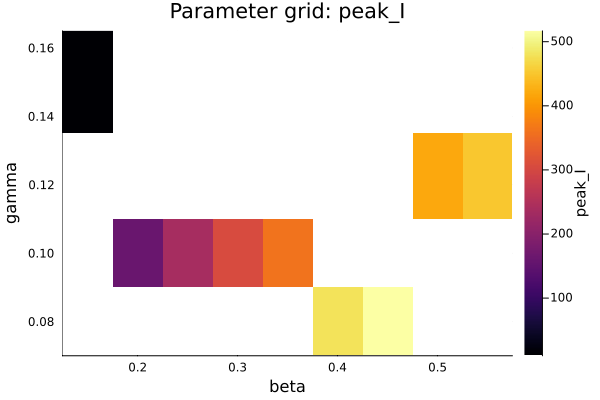

In [3]:
peak_heatmap = plot_parameter_heatmap(grid_df; metric = :peak_I)
peak_heatmap

## Тепловая карта конечного числа выздоровевших

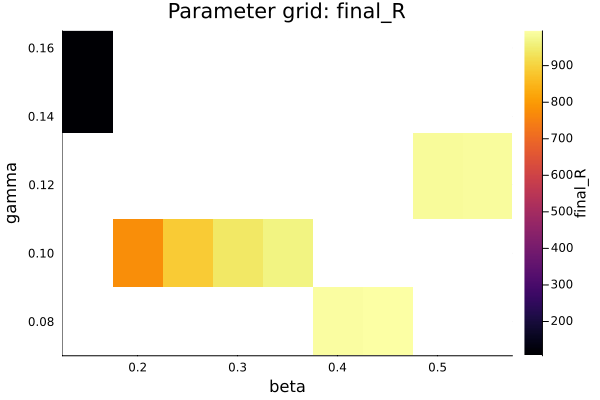

In [4]:
recovered_heatmap = plot_parameter_heatmap(grid_df; metric = :final_R)
recovered_heatmap

## Сводный ранжированный график

Для отчёта дополнительно удобно отсортировать конфигурации
по высоте эпидемического пика.

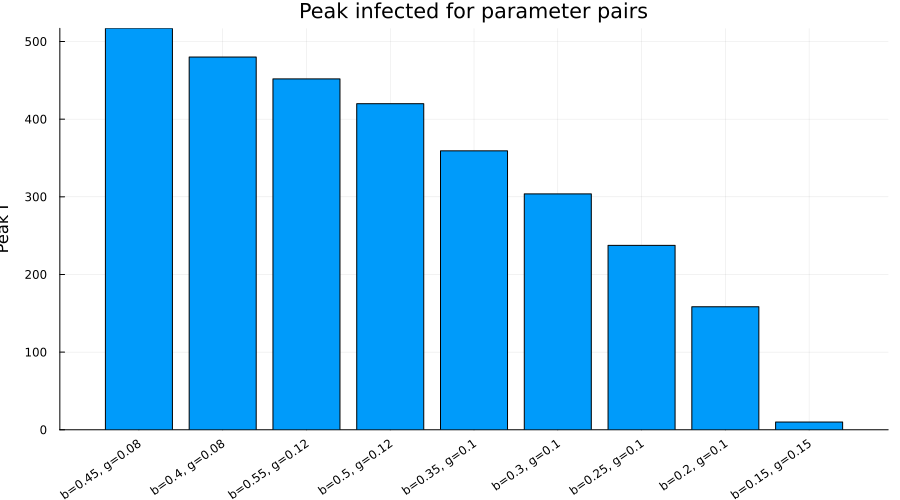

In [5]:
sorted_df = sort(grid_df, :peak_I, rev = true)
labels = ["b=$(row.beta), g=$(row.gamma)" for row in eachrow(sorted_df)]

rank_plot = bar(
    labels,
    sorted_df.peak_I;
    xlabel = "Parameter pair",
    ylabel = "Peak I",
    title = "Peak infected for parameter pairs",
    legend = false,
    xrotation = 35,
    size = (900, 500),
)
rank_plot

## Краткие выводы

1. Отношение `beta / gamma` определяет тяжесть эпидемии.
2. При повышении `beta` и снижении `gamma`
   максимум инфицированных заметно возрастает.
3. Набор параметров удобно анализировать через тепловые карты
   и ранжированные столбчатые диаграммы.